We check if the predictions from our theory match the simulations for the upcrossing process for the various correlation functions.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import torch
import os
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process
from tqdm import tqdm

plt.rcParams.update({
    "text.usetex": True,  # Enable LaTeX rendering
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"], # Specify the font (classic LaTeX font)
    # You might need to adjust the font paths or preamble depending on your setup
    # "text.latex.preamble": r"\usepackage{amsmath}" # Example if you need math packages
})

### Testing the distribution of counts of upcrossings, downcrossings and crossings.

In [2]:
# crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossingsDimless

count_method = getattr(utils, f"count_{crossing_type}s")
mean_rate_method = f"{crossing_type}_mean_rate"
mean_method = f"{crossing_type}_mean"
variance_method = f"{crossing_type}_variance"
variance_method_CLT = f"{crossing_type}_variance_CLT"
fano_method = f"{crossing_type}_fano_factor"
fano_method_CLT = f"{crossing_type}_fano_factor_CLT"

In [3]:
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$'
else:
    fano_label = r'$\mathrm{F}$'

In [4]:
# Simulation parameters.
T = 10.0                 # Total simulation time.
tau = 0.06            # Correlation decay parameter for the process.
dt = 0.1 * tau
sigma = 1.0             # Standard deviation (amplitude) of the process.
u = 0.5                 # Threshold
n_trials = 10000      # Number of simulation trials.

alpha = 3/2

# Containers for simulation results.
counts = np.zeros(n_trials, dtype=int)

# Run the simulations.
for trial in range(n_trials):
    # Simulate one sample path of the process.
    t, x = utils.simulate_gaussian_process_fft(
        process.r_rational_quadratic, T, dt, sigma=sigma, tau=tau, alpha=alpha
    )
    # Count the number at threshold u.
    counts[trial] = count_method(x, threshold=u)


# Calculate empirical statistics.
sim_mean = np.mean(counts)
sim_var = np.var(counts)
sim_fano = sim_var / sim_mean if sim_mean != 0 else np.nan

print("Simulation results:")
print(f"Mean {crossing_type}: {sim_mean:.4f}")
print(f"Variance of {crossing_type}: {sim_var:.4f}")
print(f"Fano factor (variance/mean): {sim_fano:.4f}")

Simulation results:
Mean crossing: 46.7720
Variance of crossing: 43.4534
Fano factor (variance/mean): 0.9290


In [5]:
# Compute analytical results using your GaussianUpCrossingsDimless class.
# (Note: the analytical formulas assume a dimensionless time scale with tau set to 1 in r(t).
# Here we pass tau=tau_e to keep parameters consistent with the simulation.)
model = ModelClass(r_func=process.r_rational_quadratic, u=u, tau=tau, alpha=alpha, sigma=sigma)

analytical_mean = getattr(model, mean_method)(T, u=u).item()
analytical_variance = getattr(model, variance_method)(T, u=u).item()
analytical_fano = getattr(model, fano_method)(T, u=u).item()

print("\nAnalytical results:")
print(f"Expected number of {crossing_type} (mean): {analytical_mean:.4f}")
print(f"Variance of {crossing_type}: {analytical_variance:.4f}")
print(f"Fano factor (variance/mean): {analytical_fano:.4f}")

# print the CLT results as well
analytical_variance_CLT = getattr(model, variance_method_CLT)(T, u=u).item()
analytical_fano_CLT = getattr(model, fano_method_CLT)(u=u).item()

print("\nAnalytical results using CLT:")
print(f"Variance of {crossing_type}: {analytical_variance_CLT:.4f}")
print(f"Fano factor (variance/mean): {analytical_fano_CLT:.4f}")




Analytical results:
Expected number of crossing (mean): 46.8179
Variance of crossing: 42.2843
Fano factor (variance/mean): 0.9032

Analytical results using CLT:
Variance of crossing: 42.3571
Fano factor (variance/mean): 0.9047


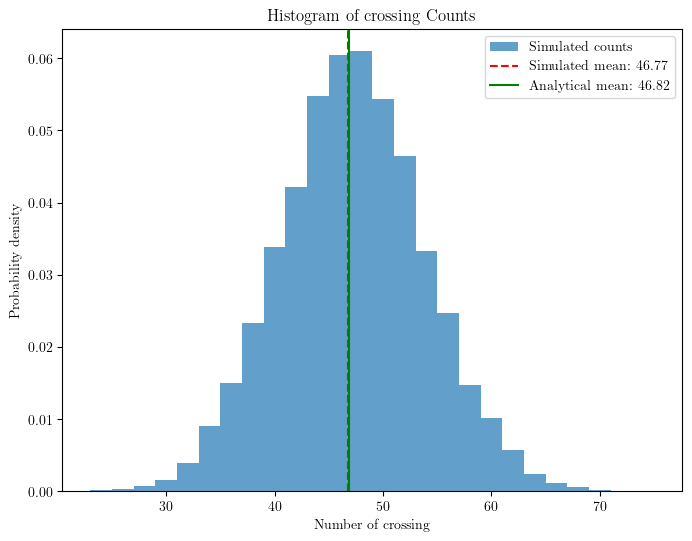

In [6]:
# Plot histogram of simulation counts with the analytical mean indicated.
plt.figure(figsize=(8, 6))
plt.hist(counts, bins=(max(counts)-min(counts)+1)//2, density=True, alpha=0.7, label="Simulated counts")
plt.axvline(sim_mean, color='r', linestyle='--', 
            label=f"Simulated mean: {sim_mean:.2f}")
plt.axvline(analytical_mean, color='g', linestyle='-', 
            label=f"Analytical mean: {analytical_mean:.2f}")
plt.xlabel(f"Number of {crossing_type}")
plt.ylabel("Probability density")
plt.title(f"Histogram of {crossing_type} Counts")
plt.legend()
plt.show()

### We simulate the analytical vs simulation results for Fano factors.

In [7]:
# which process to use
r_func = process.r_rational_quadratic

# define the parameters of the model
T = 100.0                # Total simulation time.
sigma = 1.0             # Standard deviation (amplitude) of the process.

params = {
    'tau': 1.0,
    'sigma': sigma,
    'alpha': alpha, # This will be updated below.
}

In [8]:
# define the values of u for which the result is wanted
u_list = [0.0, 0.25, 0.5]

# define the the tau values 
num_points_tau = 50
tau_min = 0.1
tau_max = 0.99
tau_vals = torch.logspace(np.log10(tau_min), np.log10(tau_max), num_points_tau)

In [9]:
# -------------------------------------------
# Save analytical results in a dictionary.
# -------------------------------------------
analytical_results = {}  # Keys are threshold u values.

for u in u_list:
    mean_vals = []
    variance_vals = []
    fano_vals = []
    
    for tau in tau_vals:
        tau_val = float(tau)
        params['tau'] = tau_val
        
        # Create GaussianUpCrossingsDimless instance with current parameters.
        model = ModelClass(r_func=r_func, u=u, **params)
        
        # Compute analytical quantities.
        mean_vals.append(getattr(model, mean_method)(T, u=u).item())
        variance_vals.append(getattr(model, variance_method)(T, u=u).item())
        fano_vals.append(getattr(model, fano_method)(T, u=u).item())
        # fano_vals.append(getattr(model, fano_method_CLT)(u=u).item())
    
    # Convert lists to torch tensors.
    analytical_results[u] = {
        'mean': torch.tensor(mean_vals),
        'variance': torch.tensor(variance_vals),
        'fano_factor': torch.tensor(fano_vals),
    }

In [10]:
# --------------------------------------------------
# Compute simulation results (using FFT simulations) and store in dictionary.
# --------------------------------------------------
# Define simulation-specific parameters.
n_trials = 2000  # Number of simulation trials.

# Define the tau values.
num_points_tau_sim = 5
tau_vals_sim = torch.logspace(np.log10(tau_min), np.log10(tau_max), num_points_tau_sim)

simulation_results = {u: {} for u in u_list}  # Prepare dictionary keys for each threshold.

# For each tau value, simulate trials and compute counts for all thresholds at once.
for tau in tqdm(tau_vals_sim, desc="Simulating over tau values"):
    tau_val = float(tau)
    params['tau'] = tau_val

    dt = 0.1 * tau_val  # Time discretization step.
    
    # Create an array to store upcrossings counts for each trial and each threshold.
    # The second dimension corresponds to each threshold in u_list.
    counts = np.zeros((n_trials, len(u_list)))
    
    for trial in tqdm(range(n_trials), desc="Trials", leave=False):
        # Generate one sample path using FFT-based simulation.
        t, x = utils.simulate_gaussian_process_fft(r_func, T, dt, **params)
        
        # Compute counts for all thresholds in one call   
        count = count_method(x, threshold=u_list)  # returns a list of counts
        
        counts[trial, :] = count
    
    # Compute simulation statistics for each threshold.
    sim_mean = np.mean(counts, axis=0)
    sim_var = np.var(counts, axis=0)
    # Compute Fano factor while avoiding division by zero.
    sim_fano = np.divide(sim_var, sim_mean, out=np.full_like(sim_var, np.nan), where=(sim_mean != 0))
    
    # Append the statistics to the results dictionary for each threshold.
    for i, u in enumerate(u_list):
        # If results for the current threshold already exist, append the new value.
        # Otherwise, initialize as a list.
        simulation_results[u].setdefault('mean', []).append(sim_mean[i])
        simulation_results[u].setdefault('variance', []).append(sim_var[i])
        simulation_results[u].setdefault('fano_factor', []).append(sim_fano[i])

# Convert lists to torch tensors for each threshold.
for u in simulation_results:
    simulation_results[u]['mean'] = torch.tensor(simulation_results[u]['mean'])
    simulation_results[u]['variance'] = torch.tensor(simulation_results[u]['variance'])
    simulation_results[u]['fano_factor'] = torch.tensor(simulation_results[u]['fano_factor'])

Simulating over tau values: 100%|██████████| 5/5 [00:22<00:00,  4.44s/it]


In [11]:
axis_label_fontsize = 28 # Fontsize for x and y labels & titles
tick_label_fontsize = 24 # Fontsize for tick labels
legend_fontsize = 24     # Fontsize for legend (matched to tick labels)
# num_x_ticks = 6        # Not directly used due to LogLocator
num_y_ticks = 4          # Desired number of ticks on the y-axis
tick_line_width = 2.0    # Thickness of tick lines
spine_line_width = 2.0   # Thickness of plot border

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


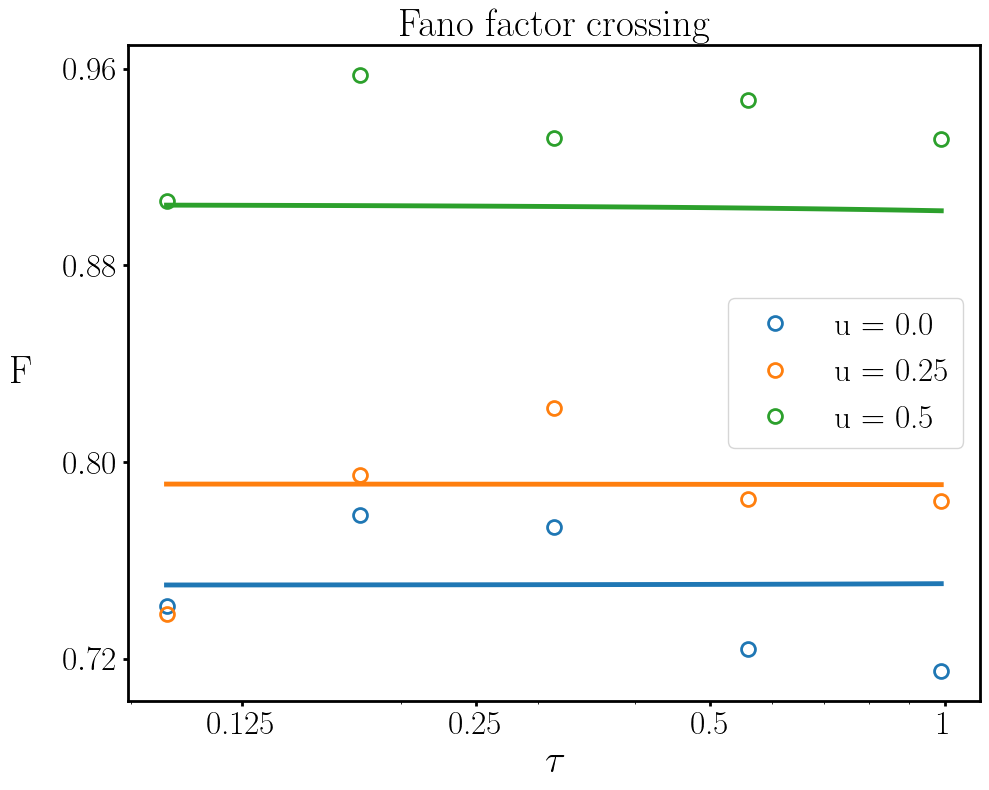

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

# Use the user's specified colormap
colors = plt.get_cmap("tab10")

for i, u in enumerate(u_list):
    analytical_fano = analytical_results[u]['fano_factor'] 
    simulation_fano = simulation_results[u]['fano_factor'] 

    # Plot the analytical curve with a thicker solid line. (User's linewidth=3)
    ax.plot(tau_vals, analytical_fano, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')

    # Plot the simulation results as open circles in the same color. (User's marker settings)
    ax.plot(tau_vals_sim, simulation_fano, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}") # Keep label format

# Apply new font sizes to title and labels
ax.set_title(f"Fano factor {crossing_type}", fontsize=axis_label_fontsize)
ax.set_xlabel(r"$\tau$", fontsize=axis_label_fontsize)
ax.set_ylabel(fano_label, fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30) # Added rotation/padding like before
ax.set_xscale('log')  # Use a logarithmic scale for the x-axis (User's choice)

# Apply new tick label size and tick line width
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Keep user's specific tick formatters/locators but adjust y-axis tick count
# Use FuncFormatter to display plain numbers on the x-axis.
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5)) 
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks))

# Apply new spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

# Only add the legend for simulation markers, apply new font size
ax.legend(fontsize=legend_fontsize)
plt.tight_layout() 

#save the figure
folder_loc = f'../../figures/rational_quadratic/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'theory_sim_fano_{crossing_type}' 
file_save_path = os.path.join(folder_loc, file_name)
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


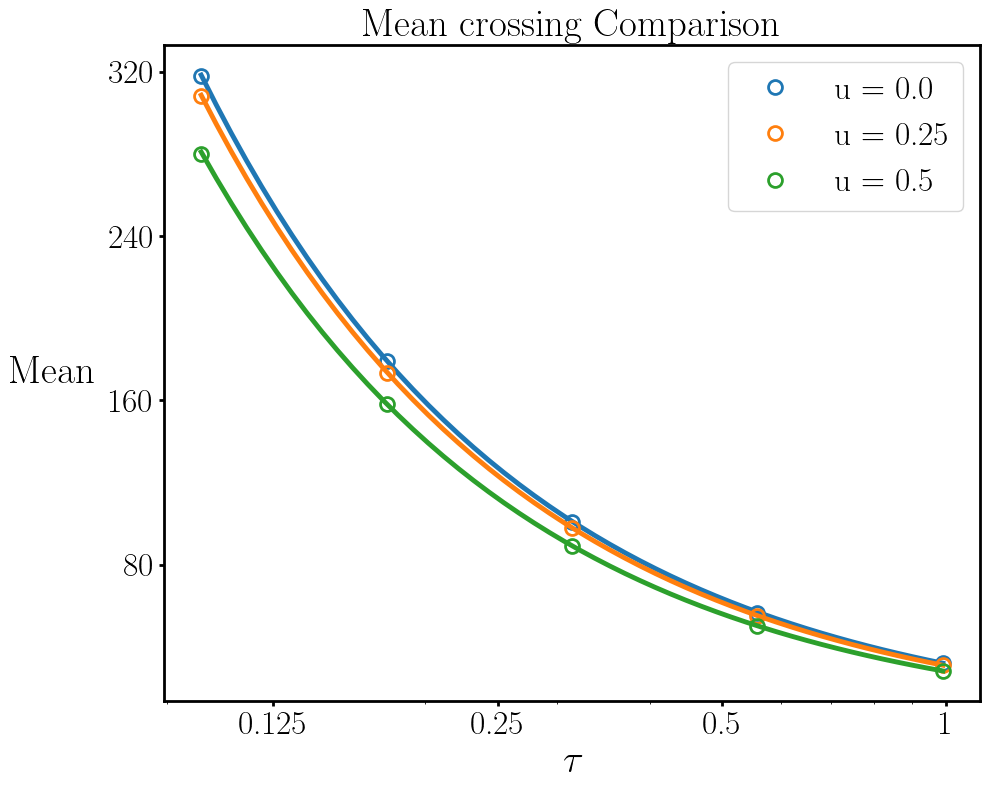

In [13]:
fig, ax = plt.subplots(figsize=(10, 8)) # Use target figure size

# Use the target colormap
colors = plt.get_cmap("tab10")

# Loop using enumerate to get index for colors, matching the target style
for i, u in enumerate(u_list):
    analytical_mean = analytical_results[u]['mean']
    simulation_mean = simulation_results[u]['mean']

    # Plot the analytical curve with a thicker solid line (target linewidth=3.5)
    ax.plot(tau_vals, analytical_mean, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')

    # Plot the simulation results as open circles in the same color (target marker settings)
    ax.plot(tau_vals_sim, simulation_mean, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}") # Keep label format

# Apply new font sizes to title and labels
ax.set_title(f"Mean {crossing_type} Comparison", fontsize=axis_label_fontsize) # Simplified title slightly
ax.set_xlabel(r"$\tau$", fontsize=axis_label_fontsize) # Use LaTeX tau
ax.set_ylabel("Mean", fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=40) # Added rotation/padding

ax.set_xscale('log') # Keep logarithmic scale for the x-axis

# Apply new tick label size and tick line width
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Keep specific tick formatters/locators but use mticker prefix and adjust y-axis ticks
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5)) # Keep base 2 log locator
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks)) # Use num_y_ticks variable

# Apply new spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

# Only add the legend for simulation markers, apply new font size
ax.legend(fontsize=legend_fontsize)
plt.tight_layout()

# --- Save the figure in multiple formats ---
# Define the folder and filename structure (adjust path as needed)
folder_loc = f'../../figures/rational_quadratic/' # Assuming same folder structure
os.makedirs(folder_loc, exist_ok=True)
file_name = f'theory_sim_mean_{crossing_type}' # Changed 'fano' to 'mean'
file_save_path = os.path.join(folder_loc, file_name)

# Save in PNG, SVG, EPS formats with specified settings
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


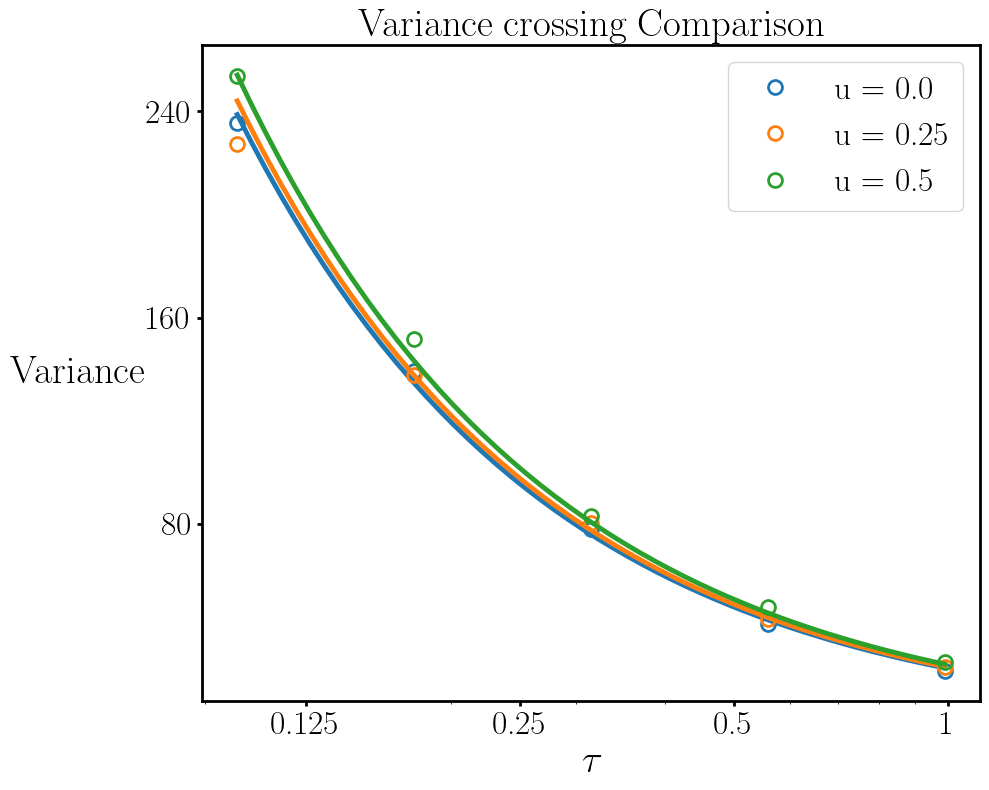

In [14]:
fig, ax = plt.subplots(figsize=(10, 8)) # Use target figure size

# Use the target colormap
colors = plt.get_cmap("tab10")

# Loop using enumerate to get index for colors, matching the target style
for i, u in enumerate(u_list):
    # Access data directly (assuming numpy arrays based on your ideal example)
    analytical_variance = analytical_results[u]['variance']
    simulation_variance = simulation_results[u]['variance']

    # Plot the analytical curve with target style (linewidth=3.5)
    ax.plot(tau_vals, analytical_variance, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')

    # Plot the simulation results with target style (markersize=10)
    ax.plot(tau_vals_sim, simulation_variance, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}") # Keep label format

# Apply new font sizes and format to title and labels
ax.set_title(f"Variance {crossing_type} Comparison", fontsize=axis_label_fontsize) # Adjusted title
ax.set_xlabel(r"$\tau$", fontsize=axis_label_fontsize) # Use LaTeX tau
ax.set_ylabel("Variance", fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=50) # Adjusted label, padding

ax.set_xscale('log') # Keep logarithmic scale for the x-axis

# Apply target tick label size and tick line width
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Apply target tick formatters/locators using mticker
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5)) # Keep base 2 log locator
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks)) # Use num_y_ticks variable

# Apply target spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

# Apply target legend font size
ax.legend(fontsize=legend_fontsize)
plt.tight_layout()

# --- Save the figure in multiple formats (target style) ---
folder_loc = f'../../figures/rational_quadratic/' # Assuming same folder structure
os.makedirs(folder_loc, exist_ok=True)
file_name = f'theory_sim_variance_{crossing_type}' # Changed 'mean' to 'variance'
file_save_path = os.path.join(folder_loc, file_name)

# Save in PNG, SVG, EPS formats with specified settings
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


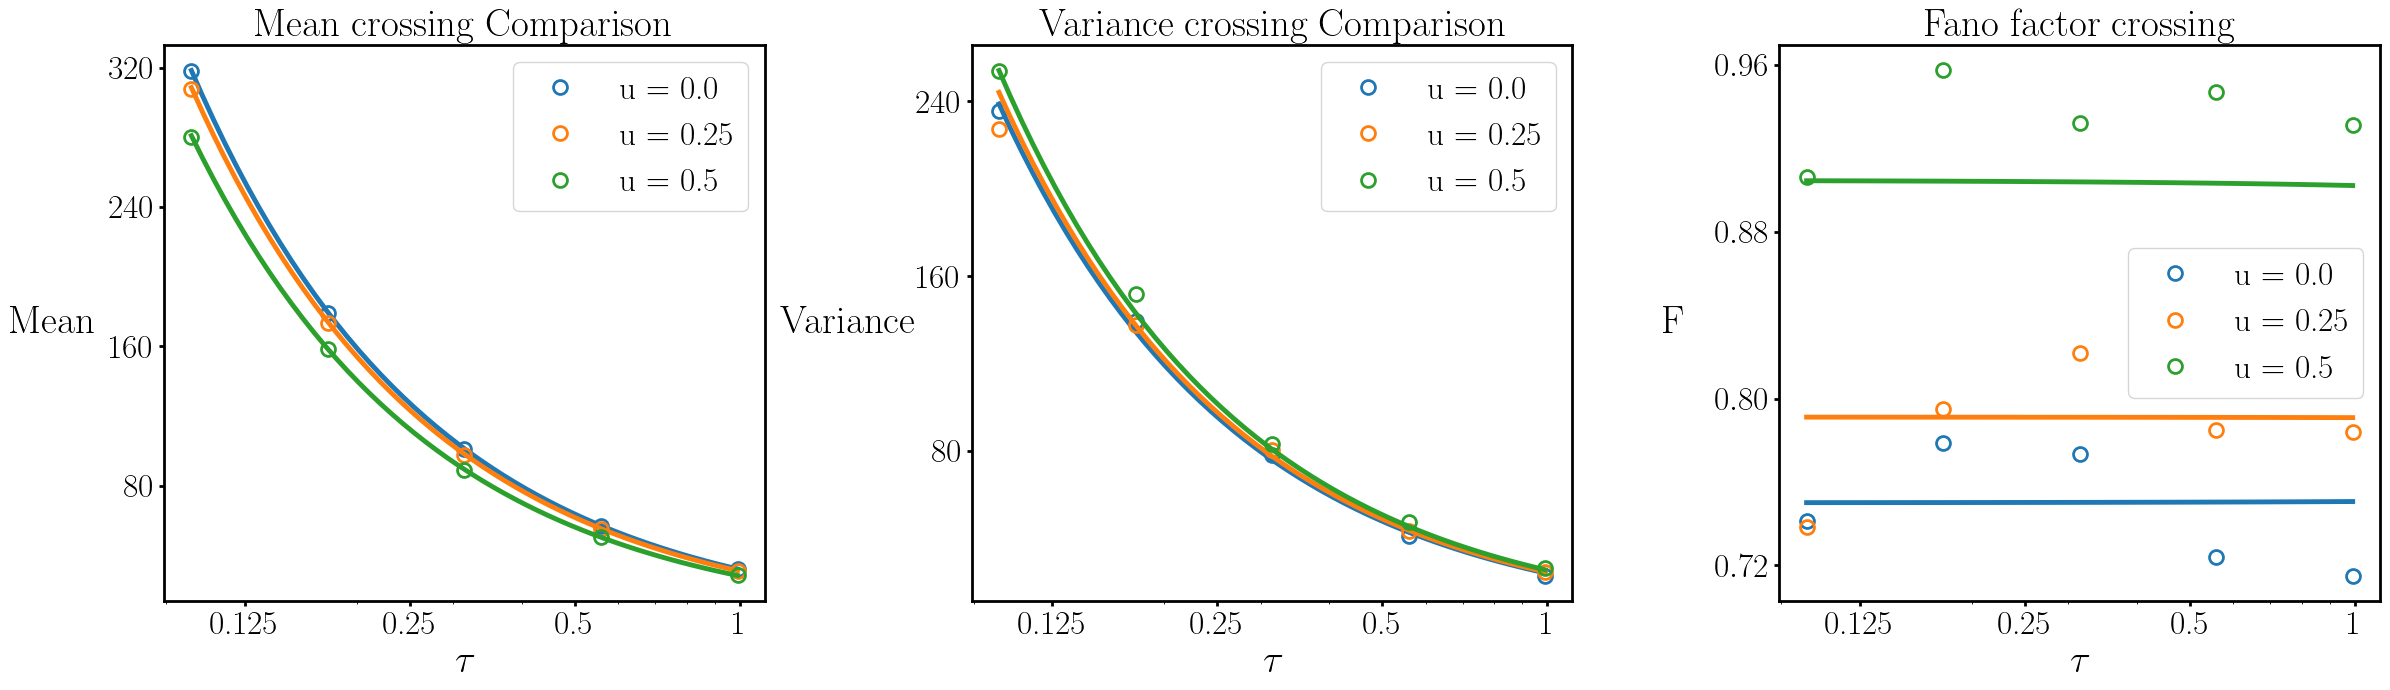

In [15]:
colors = plt.get_cmap("tab10")
# =============================================================================
# Combined Plotting Code
# =============================================================================

# Create a figure with 3 subplots (1 row, 3 columns)
# Adjust figsize as needed for aspect ratio (width might need to be ~3x height)
fig, axes = plt.subplots(1, 3, figsize=(24, 7)) # Increased width, slightly reduced height

# --- Plot Mean on the first subplot (axes[0]) ---
ax = axes[0]
for i, u in enumerate(u_list):
    analytical_mean = analytical_results[u]['mean']
    simulation_mean = simulation_results[u]['mean']
    ax.plot(tau_vals, analytical_mean, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')
    ax.plot(tau_vals_sim, simulation_mean, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title(f"Mean {crossing_type} Comparison", fontsize=axis_label_fontsize)
ax.set_xlabel(r"$\tau$", fontsize=axis_label_fontsize)
ax.set_ylabel("Mean", fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=40)
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks))
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)
ax.legend(fontsize=legend_fontsize)

# --- Plot Variance on the second subplot (axes[1]) ---
ax = axes[1]
for i, u in enumerate(u_list):
    analytical_variance = analytical_results[u]['variance']
    simulation_variance = simulation_results[u]['variance']
    ax.plot(tau_vals, analytical_variance, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')
    ax.plot(tau_vals_sim, simulation_variance, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title(f"Variance {crossing_type} Comparison", fontsize=axis_label_fontsize)
ax.set_xlabel(r"$\tau$", fontsize=axis_label_fontsize)
ax.set_ylabel("Variance", fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=50) # Keep original padding
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks))
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)
ax.legend(fontsize=legend_fontsize)

# --- Plot Fano Factor on the third subplot (axes[2]) ---
ax = axes[2]
for i, u in enumerate(u_list):
    analytical_fano = analytical_results[u]['fano_factor']
    simulation_fano = simulation_results[u]['fano_factor']
    ax.plot(tau_vals, analytical_fano, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')
    ax.plot(tau_vals_sim, simulation_fano, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title(f"Fano factor {crossing_type}", fontsize=axis_label_fontsize)
ax.set_xlabel(r"$\tau$", fontsize=axis_label_fontsize)
ax.set_ylabel(fano_label, fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30) # Keep original padding
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks))
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)
ax.legend(fontsize=legend_fontsize)

# --- Adjust layout, save the combined figure, and show ---
plt.tight_layout() # Adjust spacing between subplots

# Define folder and combined filename
folder_loc = f'../../figures/rational_quadratic/'
os.makedirs(folder_loc, exist_ok=True)
# Use a name reflecting the combined content
file_name = f'theory_sim_mean_variance_fano_{crossing_type}'
file_save_path = os.path.join(folder_loc, file_name)

# Save the entire figure in multiple formats
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()